# EMNIST Digits — K-Means on GPU
## Same preprocessing and evaluation pipeline as the CPU notebook

### Dataset
**EMNIST Digits**
- 240,000 training images available
- \(28\times28=784\) raw pixel features
- 10 digit classes
- one fixed **20,000-image** subset is used
- true digit labels are **not** used during K-Means fitting; they are used only for evaluation

### GPU design
This version deliberately uses:
- **GPU:** RAPIDS cuML `KMeans`
- **NVIDIA CUDA GPU required**
- **No scikit-learn K-Means for fitting**
- scikit-learn is still used for preprocessing and evaluation metrics

### Pipeline kept the same
1. Load EMNIST Digits
2. Select the same-size fixed 20,000-image subset
3. Correct EMNIST image orientation
4. Flatten \(28\times28 \rightarrow 784\)
5. Normalize pixels to `[0,1]`
6. Standardize features on CPU
7. Reduce to **50 PCA components on CPU**
8. Run **GPU K-Means with \(K=10\)**
9. Repeat the clustering **3 times**
10. Measure fit time, throughput, peak host RAM, GPU/total energy, and CO₂e
11. Compute the same external and internal clustering-quality metrics
12. Plot results and save CSV/PNG outputs

> **Kaggle:** enable a GPU accelerator before running this notebook.


## 1. Install and import packages

In [1]:
import subprocess
import sys
import importlib.util
import re
from pathlib import Path

def ensure_package(module_name, package_name=None):
    if importlib.util.find_spec(module_name) is None:
        subprocess.check_call([
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            package_name or module_name,
        ])

ensure_package("codecarbon")

# ------------------------------------------------------------
# RAPIDS / cuML setup
# ------------------------------------------------------------
try:
    smi_text = subprocess.check_output(
        ["nvidia-smi"],
        text=True,
        stderr=subprocess.STDOUT,
    )
except Exception as exc:
    raise RuntimeError(
        "No NVIDIA GPU was detected. In Kaggle, enable a GPU accelerator "
        "in Notebook Settings and restart the session."
    ) from exc

cuda_major = None

# Prefer the installed CUDA toolkit version.
try:
    nvcc_text = subprocess.check_output(
        ["nvcc", "--version"],
        text=True,
        stderr=subprocess.STDOUT,
    )
    match = re.search(r"release\s+(\d+)", nvcc_text)
    if match:
        cuda_major = int(match.group(1))
except Exception:
    pass

# Fallback to the CUDA version shown by nvidia-smi.
if cuda_major is None:
    match = re.search(r"CUDA Version:\s*(\d+)", smi_text)
    if match:
        cuda_major = int(match.group(1))

if cuda_major not in (12, 13):
    raise RuntimeError(
        f"Detected CUDA major version {cuda_major}. "
        "This notebook expects CUDA 12 or CUDA 13."
    )

if importlib.util.find_spec("cuml") is None:
    rapids_pkg = f"cuml-cu{cuda_major}"
    print(f"Installing {rapids_pkg} ...")

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        rapids_pkg,
        "--extra-index-url=https://pypi.nvidia.com",
    ])

# ------------------------------------------------------------
# Normal imports
# ------------------------------------------------------------
import os
import gc
import time
import random
import platform
import threading
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import psutil

import torch
from torchvision import datasets

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    adjusted_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
)

from codecarbon import EmissionsTracker

import cuml
import cupy as cp
from cuml.cluster import KMeans as CUKMeans

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

HAS_CUDA = torch.cuda.is_available()

if not HAS_CUDA:
    raise RuntimeError(
        "PyTorch cannot access CUDA. Enable a Kaggle GPU accelerator "
        "and restart the notebook session."
    )

print("Environment")
print("Python:", platform.python_version())
print("PyTorch:", torch.__version__)
print("cuML:", cuml.__version__)
print("CPU:", platform.processor() or "OS-reported CPU")
print("Logical CPU cores:", os.cpu_count())
print("CUDA available:", HAS_CUDA)
print("GPU:", torch.cuda.get_device_name(0))
print("PyTorch CUDA:", torch.version.cuda)
print("RAPIDS wheel CUDA major:", cuda_major)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.9/396.9 kB 24.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.0/71.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.6/155.6 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 109.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 108.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 111.8 MB/s eta 0:00:00


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
sigstore 4.3.0 requires cryptography<49,>=42, but you have cryptography 50.0.0 which is incompatible.
pydrive2 1.21.3 requires cryptography<44, but you have cryptography 50.0.0 which is incompatible.
pyopenssl 24.2.1 requires cryptography<44,>=41.0.5, but you have cryptography 50.0.0 which is incompatible.


Environment
Python: 3.12.13
PyTorch: 2.10.0+cu128
cuML: 26.02.000
CPU: x86_64
Logical CPU cores: 4
CUDA available: True
GPU: Tesla T4
PyTorch CUDA: 12.8
RAPIDS wheel CUDA major: 12


## 2. Controlled experimental configuration

In [2]:
SEED = 42

CLUSTERING_SAMPLES = 20_000
PCA_DIMS = 50

K = 10
KMEANS_N_INIT = 10
KMEANS_MAX_ITER = 300
KMEANS_TOL = 1e-4

N_REPEATS = 3
SILHOUETTE_SAMPLE_SIZE = 10_000
CARBON_MEASURE_SECS = 1

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

print({
    "clustering samples": CLUSTERING_SAMPLES,
    "PCA dimensions": PCA_DIMS,
    "K": K,
    "n_init": KMEANS_N_INIT,
    "max_iter": KMEANS_MAX_ITER,
    "tol": KMEANS_TOL,
    "repetitions": N_REPEATS,
    "silhouette sample": SILHOUETTE_SAMPLE_SIZE,
    "device": "GPU",
    "backend": "cuML",
})


{'clustering samples': 20000, 'PCA dimensions': 50, 'K': 10, 'n_init': 10, 'max_iter': 300, 'tol': 0.0001, 'repetitions': 3, 'silhouette sample': 10000, 'device': 'GPU', 'backend': 'cuML'}


## 3. Load and preview EMNIST Digits

100%|██████████| 562M/562M [00:01<00:00, 405MB/s]


Dataset: EMNIST Digits
Training images: 240000
Raw image size: (28, 28)
Raw flattened features: 784
Classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


,digit,count
0,0,24000
1,1,24000
2,2,24000
3,3,24000
4,4,24000
5,5,24000
6,6,24000
7,7,24000
8,8,24000
9,9,24000


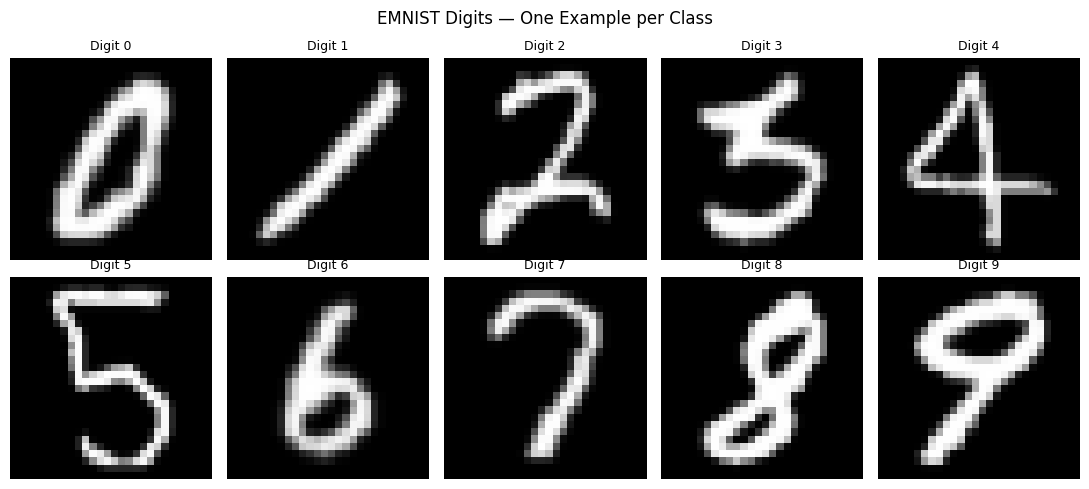

In [3]:
dataset = datasets.EMNIST(
    "./data",
    split="digits",
    train=True,
    download=True,
)

print("Dataset: EMNIST Digits")
print("Training images:", len(dataset))
print("Raw image size:", tuple(dataset.data.shape[1:]))
print("Raw flattened features:", int(np.prod(dataset.data.shape[1:])))
print("Classes:", sorted(dataset.targets.unique().tolist()))

counts = np.bincount(
    dataset.targets.numpy(),
    minlength=10,
)

display(
    pd.DataFrame({
        "digit": np.arange(10),
        "count": counts,
    })
)

fig, axes = plt.subplots(2, 5, figsize=(11, 5))
targets_np = dataset.targets.numpy()

for digit, ax in enumerate(axes.ravel()):
    idx = int(np.flatnonzero(targets_np == digit)[0])

    # EMNIST is stored transposed relative to conventional display.
    ax.imshow(
        dataset.data[idx].numpy().T,
        cmap="gray",
    )
    ax.set_title(f"Digit {digit}", fontsize=9)
    ax.axis("off")

fig.suptitle("EMNIST Digits — One Example per Class")
fig.tight_layout()
fig.savefig("emnist_kmeans_cpu_dataset_preview.png", dpi=160)
plt.show()


## 4. Build the feature matrix

Preprocessing is performed **once on CPU** and excluded from GPU K-Means fit time:

1. select one fixed shuffled **20,000-image** subset;
2. orient each image correctly;
3. flatten \(28\times28\rightarrow784\);
4. normalize pixels to `[0,1]`;
5. standardize features;
6. reduce to 50 PCA components.

The resulting NumPy matrix is supplied to cuML K-Means. cuML accepts host NumPy
arrays and performs the required GPU-side conversion internally. This keeps the
preprocessing pipeline identical to the CPU notebook.


In [4]:
def build_features():
    rng = np.random.RandomState(SEED)
    n_total = len(dataset)

    if CLUSTERING_SAMPLES > n_total:
        raise ValueError(
            f"CLUSTERING_SAMPLES={CLUSTERING_SAMPLES:,} "
            f"exceeds dataset size {n_total:,}."
        )

    # One fixed set of observations for every repetition.
    shared_indices = rng.permutation(n_total)[:CLUSTERING_SAMPLES]

    raw = dataset.data[shared_indices]
    labels = (
        dataset.targets[shared_indices]
        .numpy()
        .astype(np.int32)
    )

    # Correct EMNIST orientation, flatten, normalize.
    X = (
        raw.float()
        .transpose(1, 2)
        .contiguous()
        .view(len(shared_indices), -1)
        .numpy()
        / 255.0
    ).astype(np.float32)

    preprocessing_start = time.perf_counter()

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X).astype(np.float32)

    pca = PCA(
        n_components=PCA_DIMS,
        svd_solver="randomized",
        random_state=SEED,
    )

    X_pca = pca.fit_transform(X_scaled).astype(np.float32)
    preprocessing_time_s = time.perf_counter() - preprocessing_start

    return (
        X_pca,
        labels,
        shared_indices,
        preprocessing_time_s,
        pca.explained_variance_ratio_.sum(),
    )

X_shared, y_shared, shared_indices, preprocessing_time_s, pca_variance = (
    build_features()
)

print("K-Means matrix:", X_shared.shape)
print("Labels:", y_shared.shape)
print(f"Preprocessing time (excluded from fit benchmark): {preprocessing_time_s:.3f} s")
print(f"PCA explained variance retained: {pca_variance:.4f}")

assert X_shared.shape == (CLUSTERING_SAMPLES, PCA_DIMS)
assert len(y_shared) == CLUSTERING_SAMPLES


K-Means matrix: (20000, 50)
Labels: (20000,)
Preprocessing time (excluded from fit benchmark): 2.431 s
PCA explained variance retained: 0.7277


## 5. CodeCarbon and peak-memory helpers

In [5]:
process = psutil.Process(os.getpid())


class PeakMemory:
    def __init__(self, interval=0.10):
        self.interval = interval
        self.peak_rss = 0
        self.stop_event = threading.Event()
        self.thread = None

    def _watch(self):
        while not self.stop_event.is_set():
            try:
                self.peak_rss = max(
                    self.peak_rss,
                    process.memory_info().rss,
                )
            except Exception:
                pass
            time.sleep(self.interval)

    def start(self):
        self.peak_rss = process.memory_info().rss
        self.stop_event.clear()
        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )
        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(timeout=2)

        return self.peak_rss / (1024 ** 2)


class GPUMemory:
    # Samples total memory used on GPU 0 through nvidia-smi.
    def __init__(self, interval=0.10):
        self.interval = interval
        self.peak_mb = np.nan
        self.stop_event = threading.Event()
        self.thread = None

    @staticmethod
    def _read_used_mb():
        try:
            output = subprocess.check_output(
                [
                    "nvidia-smi",
                    "--query-gpu=memory.used",
                    "--format=csv,noheader,nounits",
                    "-i",
                    "0",
                ],
                text=True,
                stderr=subprocess.DEVNULL,
            )
            return float(output.strip().splitlines()[0])
        except Exception:
            return np.nan

    def _watch(self):
        current = self._read_used_mb()

        if not np.isnan(current):
            self.peak_mb = current

        while not self.stop_event.is_set():
            current = self._read_used_mb()

            if not np.isnan(current):
                if np.isnan(self.peak_mb):
                    self.peak_mb = current
                else:
                    self.peak_mb = max(self.peak_mb, current)

            time.sleep(self.interval)

    def start(self):
        self.peak_mb = self._read_used_mb()
        self.stop_event.clear()
        self.thread = threading.Thread(
            target=self._watch,
            daemon=True,
        )
        self.thread.start()

    def stop(self):
        self.stop_event.set()

        if self.thread is not None:
            self.thread.join(timeout=2)

        return self.peak_mb


class EnergyTracker:
    def __init__(self, project_name):
        self.tracker = None

        try:
            kwargs = dict(
                project_name=project_name,
                measure_power_secs=CARBON_MEASURE_SECS,
                tracking_mode="process",
                gpu_ids=[0],
                log_level="error",
            )

            try:
                self.tracker = EmissionsTracker(
                    output_methods=[],
                    **kwargs,
                )
            except TypeError:
                self.tracker = EmissionsTracker(
                    save_to_file=False,
                    save_to_api=False,
                    **kwargs,
                )

        except Exception as exc:
            print("CodeCarbon initialization unavailable:", exc)

    def start(self):
        if self.tracker is not None:
            try:
                self.tracker.start()
            except Exception as exc:
                print("CodeCarbon start failed:", exc)
                self.tracker = None

    def stop(self):
        if self.tracker is None:
            return self.empty()

        try:
            self.tracker.stop()

            data = getattr(
                self.tracker,
                "final_emissions_data",
                None,
            )

            if data is None:
                return self.empty()

            def attr(name):
                value = getattr(data, name, np.nan)
                return np.nan if value is None else value

            return {
                "energy_kwh": attr("energy_consumed"),
                "co2_kg": attr("emissions"),
                "cpu_energy_kwh": attr("cpu_energy"),
                "gpu_energy_kwh": attr("gpu_energy"),
                "ram_energy_kwh": attr("ram_energy"),
                "cpu_power_w": attr("cpu_power"),
                "gpu_power_w": attr("gpu_power"),
                "cpu_utilization_pct": attr("cpu_utilization_percent"),
                "gpu_utilization_pct": attr("gpu_utilization_percent"),
                "country": getattr(data, "country_name", None),
            }

        except Exception as exc:
            print("CodeCarbon stop failed:", exc)
            return self.empty()

    @staticmethod
    def empty():
        return {
            "energy_kwh": np.nan,
            "co2_kg": np.nan,
            "cpu_energy_kwh": np.nan,
            "gpu_energy_kwh": np.nan,
            "ram_energy_kwh": np.nan,
            "cpu_power_w": np.nan,
            "gpu_power_w": np.nan,
            "cpu_utilization_pct": np.nan,
            "gpu_utilization_pct": np.nan,
            "country": None,
        }


def gpu_sync():
    cp.cuda.Stream.null.synchronize()


def to_numpy(value):
    if isinstance(value, np.ndarray):
        return value

    try:
        return cp.asnumpy(value)
    except Exception:
        pass

    for attr_name in ("to_numpy", "values_host", "get"):
        if hasattr(value, attr_name):
            try:
                attr = getattr(value, attr_name)
                return np.asarray(attr())
            except Exception:
                pass

    return np.asarray(value)


## 6. GPU K-Means estimator


In [6]:
def make_kmeans(run_seed):
    return CUKMeans(
        n_clusters=K,
        init="k-means++",
        n_init=KMEANS_N_INIT,
        max_iter=KMEANS_MAX_ITER,
        tol=KMEANS_TOL,
        random_state=run_seed,
        output_type="cupy",
    )

print("K-Means GPU settings:")
print({
    "backend": "cuML",
    "n_clusters": K,
    "init": "k-means++",
    "n_init": KMEANS_N_INIT,
    "max_iter": KMEANS_MAX_ITER,
    "tol": KMEANS_TOL,
})


K-Means GPU settings:
{'backend': 'cuML', 'n_clusters': 10, 'init': 'k-means++', 'n_init': 10, 'max_iter': 300, 'tol': 0.0001}


## 7. Clustering quality metrics

The true digit labels are used **only after fitting**.

### External metrics
- NMI
- AMI
- ARI
- Homogeneity
- Completeness
- V-measure

### Internal metrics
- Silhouette score
- Davies–Bouldin index
- Calinski–Harabasz score

Silhouette is calculated on at most 10,000 points to avoid an unnecessary
\(O(n^2)\) full 20,000-point calculation.


In [7]:
def safe_silhouette_subset(labels, max_samples, seed):
    labels = np.asarray(labels)
    n = len(labels)
    unique_labels = np.unique(labels)

    if n < 3 or len(unique_labels) < 2:
        return None

    target_n = min(max_samples, n)
    rng = np.random.RandomState(seed)

    # Guarantee that more than one cluster is represented.
    chosen = []

    shuffled_clusters = unique_labels.copy()
    rng.shuffle(shuffled_clusters)

    for cluster_id in shuffled_clusters[:target_n]:
        cluster_indices = np.flatnonzero(labels == cluster_id)

        if len(cluster_indices) > 0:
            chosen.append(int(rng.choice(cluster_indices)))

    chosen = np.asarray(chosen, dtype=np.int64)

    remaining_slots = target_n - len(chosen)

    if remaining_slots > 0:
        available = np.setdiff1d(
            np.arange(n),
            chosen,
            assume_unique=False,
        )

        extra_n = min(remaining_slots, len(available))

        if extra_n > 0:
            extra = rng.choice(
                available,
                size=extra_n,
                replace=False,
            )
            chosen = np.concatenate([chosen, extra])

    rng.shuffle(chosen)

    sampled_labels = labels[chosen]

    if (
        len(np.unique(sampled_labels)) < 2
        or len(np.unique(sampled_labels)) >= len(sampled_labels)
    ):
        return None

    return chosen


def clustering_metrics(X, predicted, true_labels, metric_seed):
    labels = np.asarray(predicted).reshape(-1)
    y_true = np.asarray(true_labels).reshape(-1)

    unique_clusters = np.unique(labels)
    n_clusters = len(unique_clusters)

    # External metrics: labels are used only here, after unsupervised fitting.
    nmi = normalized_mutual_info_score(y_true, labels)
    ami = adjusted_mutual_info_score(y_true, labels)
    ari = adjusted_rand_score(y_true, labels)
    homogeneity = homogeneity_score(y_true, labels)
    completeness = completeness_score(y_true, labels)
    v_measure = v_measure_score(y_true, labels)

    silhouette = np.nan
    davies_bouldin = np.nan
    calinski_harabasz = np.nan

    valid_internal = (
        len(X) >= 3
        and n_clusters >= 2
        and n_clusters < len(X)
    )

    if valid_internal:
        sample_idx = safe_silhouette_subset(
            labels=labels,
            max_samples=SILHOUETTE_SAMPLE_SIZE,
            seed=metric_seed,
        )

        if sample_idx is not None:
            try:
                silhouette = silhouette_score(
                    X[sample_idx],
                    labels[sample_idx],
                    metric="euclidean",
                )
            except ValueError as exc:
                print("Silhouette skipped:", exc)

        try:
            davies_bouldin = davies_bouldin_score(X, labels)
        except ValueError as exc:
            print("Davies-Bouldin skipped:", exc)

        try:
            calinski_harabasz = calinski_harabasz_score(X, labels)
        except ValueError as exc:
            print("Calinski-Harabasz skipped:", exc)

    return {
        "n_clusters": n_clusters,
        "noise_fraction": 0.0,  # K-Means assigns every point.
        "nmi_all": nmi,
        "ami_all": ami,
        "ari_all": ari,
        "homogeneity": homogeneity,
        "completeness": completeness,
        "v_measure": v_measure,
        "silhouette": silhouette,
        "davies_bouldin": davies_bouldin,
        "calinski_harabasz": calinski_harabasz,
    }


## 8. Run one GPU K-Means configuration


In [8]:
def run_one_kmeans_gpu(X, y, run_seed, repeat):
    estimator = make_kmeans(run_seed)

    tracker = EnergyTracker(
        project_name=f"emnist-kmeans-gpu-r{repeat}"
    )

    host_memory = PeakMemory()
    gpu_memory = GPUMemory()

    tracker.start()
    host_memory.start()
    gpu_memory.start()

    gpu_sync()
    start = time.perf_counter()

    predicted = estimator.fit_predict(X)

    gpu_sync()
    fit_time_s = time.perf_counter() - start

    peak_process_ram_mb = host_memory.stop()
    peak_gpu_memory_mb = gpu_memory.stop()
    environmental = tracker.stop()

    # Device-to-host conversion is outside the timed fit region.
    labels = to_numpy(
        predicted
    ).astype(
        np.int32,
        copy=False,
    )

    metrics = clustering_metrics(
        X=X,
        predicted=labels,
        true_labels=y,
        metric_seed=run_seed,
    )

    print(
        f"KMeans | GPU | "
        f"repeat={repeat} | "
        f"n={len(X):,} | "
        f"fit={fit_time_s:.3f}s | "
        f"clusters={metrics['n_clusters']} | "
        f"NMI={metrics['nmi_all']:.3f} | "
        f"ARI={metrics['ari_all']:.3f}"
    )

    return {
        "repeat": repeat,
        "seed": run_seed,
        "algorithm": "KMeans",
        "device": "gpu",
        "backend": "cuml",
        "n_samples": len(X),
        "n_features": X.shape[1],
        "fit_time_s": fit_time_s,
        "throughput_samples_s": len(X) / fit_time_s,
        "peak_process_ram_mb": peak_process_ram_mb,
        "peak_gpu_memory_mb": peak_gpu_memory_mb,

        **metrics,

        "energy_kwh": environmental["energy_kwh"],
        "co2_kg": environmental["co2_kg"],
        "cpu_energy_kwh": environmental["cpu_energy_kwh"],
        "gpu_energy_kwh": environmental["gpu_energy_kwh"],
        "ram_energy_kwh": environmental["ram_energy_kwh"],
        "cpu_power_w": environmental["cpu_power_w"],
        "gpu_power_w": environmental["gpu_power_w"],
        "cpu_utilization_pct": environmental["cpu_utilization_pct"],
        "gpu_utilization_pct": environmental["gpu_utilization_pct"],
        "carbon_country": environmental["country"],
        "labels": labels,
    }


## 9. Repeated GPU benchmark


In [9]:
results = []

for repeat_idx in range(N_REPEATS):
    repeat = repeat_idx + 1
    run_seed = SEED + repeat_idx

    print("\n" + "=" * 80)
    print(
        f"REPETITION {repeat}/{N_REPEATS} "
        f"| seed={run_seed} "
        f"| K-Means GPU"
    )
    print("=" * 80)

    gc.collect()

    try:
        cp.get_default_memory_pool().free_all_blocks()
        cp.get_default_pinned_memory_pool().free_all_blocks()
    except Exception:
        pass

    result = run_one_kmeans_gpu(
        X=X_shared,
        y=y_shared,
        run_seed=run_seed,
        repeat=repeat,
    )

    results.append(result)


raw_df = pd.DataFrame([
    {
        key: value
        for key, value in result.items()
        if key != "labels"
    }
    for result in results
])

raw_df["co2_g"] = raw_df["co2_kg"] * 1000
raw_df["energy_wh"] = raw_df["energy_kwh"] * 1000

raw_df["energy_wh_per_1000_samples"] = (
    raw_df["energy_wh"]
    / raw_df["n_samples"]
    * 1000
)

display(raw_df.round(6))



REPETITION 1/3 | seed=42 | K-Means GPU


[codecarbon WARNING @ 09:08:23] Multiple instances of codecarbon are allowed to run at the same time.


KMeans | GPU | repeat=1 | n=20,000 | fit=1.094s | clusters=10 | NMI=0.453 | ARI=0.353

REPETITION 2/3 | seed=43 | K-Means GPU
KMeans | GPU | repeat=2 | n=20,000 | fit=0.289s | clusters=10 | NMI=0.452 | ARI=0.352

REPETITION 3/3 | seed=44 | K-Means GPU
KMeans | GPU | repeat=3 | n=20,000 | fit=0.298s | clusters=10 | NMI=0.452 | ARI=0.353


,repeat,seed,algorithm,device,backend,n_samples,n_features,fit_time_s,throughput_samples_s,peak_process_ram_mb,peak_gpu_memory_mb,n_clusters,noise_fraction,nmi_all,ami_all,ari_all,homogeneity,completeness,v_measure,silhouette,davies_bouldin,calinski_harabasz,energy_kwh,co2_kg,cpu_energy_kwh,gpu_energy_kwh,ram_energy_kwh,cpu_power_w,gpu_power_w,cpu_utilization_pct,gpu_utilization_pct,carbon_country,co2_g,energy_wh,energy_wh_per_1000_samples
0,1,42,KMeans,gpu,cuml,20000,50,1.093667,18287.105126,1525.066406,113.0,10,0.0,0.452800,0.452310,0.353174,0.446215,0.459581,0.452800,0.059727,2.594028,803.959534,0.000018,0.000004,0.000001,0.000013,0.000004,3.170940,21.428920,0,0,United States,0.003958,0.018114,0.000906
1,2,43,KMeans,gpu,cuml,20000,50,0.288602,69299.499968,1552.597656,113.0,10,0.0,0.451561,0.451071,0.351804,0.444963,0.458358,0.451561,0.061433,2.591796,803.894531,0.000007,0.000001,0.000000,0.000005,0.000001,1.290455,19.420513,0,0,United States,0.001481,0.006775,0.000339
2,3,44,KMeans,gpu,cuml,20000,50,0.297887,67139.593487,1553.808594,113.0,10,0.0,0.452234,0.451744,0.352506,0.445659,0.459006,0.452234,0.060314,2.591563,803.896667,0.000006,0.000001,0.000000,0.000004,0.000001,1.339942,16.987206,0,0,United States,0.001337,0.006116,0.000306


## 10. Mean ± standard deviation summary

In [10]:
summary_df = pd.DataFrame([{
    "algorithm": "KMeans",
    "device": "gpu",
    "backend": "cuml",
    "n_samples": int(raw_df["n_samples"].iloc[0]),

    "fit_time_mean_s": raw_df["fit_time_s"].mean(),
    "fit_time_std_s": raw_df["fit_time_s"].std(),

    "throughput_mean_samples_s": raw_df["throughput_samples_s"].mean(),
    "throughput_std_samples_s": raw_df["throughput_samples_s"].std(),

    "n_clusters_mean": raw_df["n_clusters"].mean(),

    "nmi_mean": raw_df["nmi_all"].mean(),
    "nmi_std": raw_df["nmi_all"].std(),

    "ari_mean": raw_df["ari_all"].mean(),
    "ari_std": raw_df["ari_all"].std(),

    "ami_mean": raw_df["ami_all"].mean(),
    "ami_std": raw_df["ami_all"].std(),

    "silhouette_mean": raw_df["silhouette"].mean(),
    "silhouette_std": raw_df["silhouette"].std(),

    "davies_bouldin_mean": raw_df["davies_bouldin"].mean(),
    "davies_bouldin_std": raw_df["davies_bouldin"].std(),

    "calinski_harabasz_mean": raw_df["calinski_harabasz"].mean(),
    "calinski_harabasz_std": raw_df["calinski_harabasz"].std(),

    "energy_mean_kwh": raw_df["energy_kwh"].mean(),
    "energy_std_kwh": raw_df["energy_kwh"].std(),

    "gpu_energy_mean_kwh": raw_df["gpu_energy_kwh"].mean(),
    "gpu_energy_std_kwh": raw_df["gpu_energy_kwh"].std(),

    "co2_mean_g": raw_df["co2_g"].mean(),
    "co2_std_g": raw_df["co2_g"].std(),

    "peak_host_ram_mean_mb": raw_df["peak_process_ram_mb"].mean(),
    "peak_host_ram_std_mb": raw_df["peak_process_ram_mb"].std(),

    "peak_gpu_memory_mean_mb": raw_df["peak_gpu_memory_mb"].mean(),
    "peak_gpu_memory_std_mb": raw_df["peak_gpu_memory_mb"].std(),
}])

display(summary_df.round(6))


,algorithm,device,backend,n_samples,fit_time_mean_s,fit_time_std_s,throughput_mean_samples_s,throughput_std_samples_s,n_clusters_mean,nmi_mean,nmi_std,ari_mean,ari_std,ami_mean,ami_std,silhouette_mean,silhouette_std,davies_bouldin_mean,davies_bouldin_std,calinski_harabasz_mean,calinski_harabasz_std,energy_mean_kwh,energy_std_kwh,gpu_energy_mean_kwh,gpu_energy_std_kwh,co2_mean_g,co2_std_g,peak_host_ram_mean_mb,peak_host_ram_std_mb,peak_gpu_memory_mean_mb,peak_gpu_memory_std_mb
0,KMeans,gpu,cuml,20000,0.560052,0.462147,51575.399527,28848.729732,10.0,0.452198,0.00062,0.352495,0.000685,0.451708,0.00062,0.060491,0.000867,2.592462,0.001361,803.916931,0.036928,0.00001,0.000007,0.000007,0.000005,0.002259,0.001474,1543.824219,16.256022,113.0,0.0


## 11. Fit time and throughput

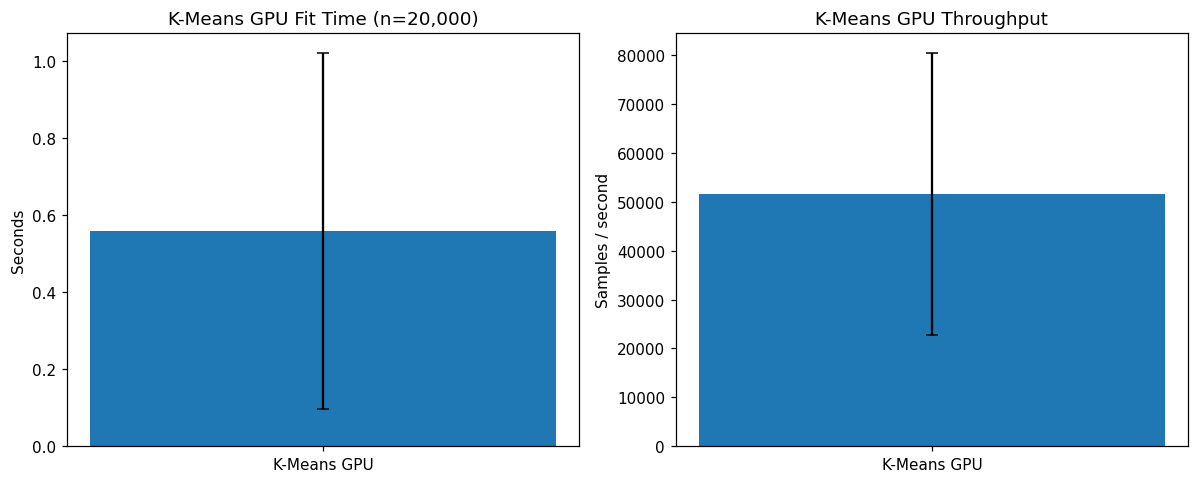

In [11]:
plt.rcParams.update({
    "figure.dpi": 110,
    "font.size": 10,
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].bar(
    ["K-Means GPU"],
    [raw_df["fit_time_s"].mean()],
    yerr=[raw_df["fit_time_s"].std()],
    capsize=4,
)
axes[0].set_title(
    f"K-Means GPU Fit Time (n={CLUSTERING_SAMPLES:,})"
)
axes[0].set_ylabel("Seconds")

axes[1].bar(
    ["K-Means GPU"],
    [raw_df["throughput_samples_s"].mean()],
    yerr=[raw_df["throughput_samples_s"].std()],
    capsize=4,
)
axes[1].set_title("K-Means GPU Throughput")
axes[1].set_ylabel("Samples / second")

plt.tight_layout()
plt.savefig("emnist_kmeans_gpu_timing.png", dpi=160)
plt.show()


## 12. External clustering-quality plots

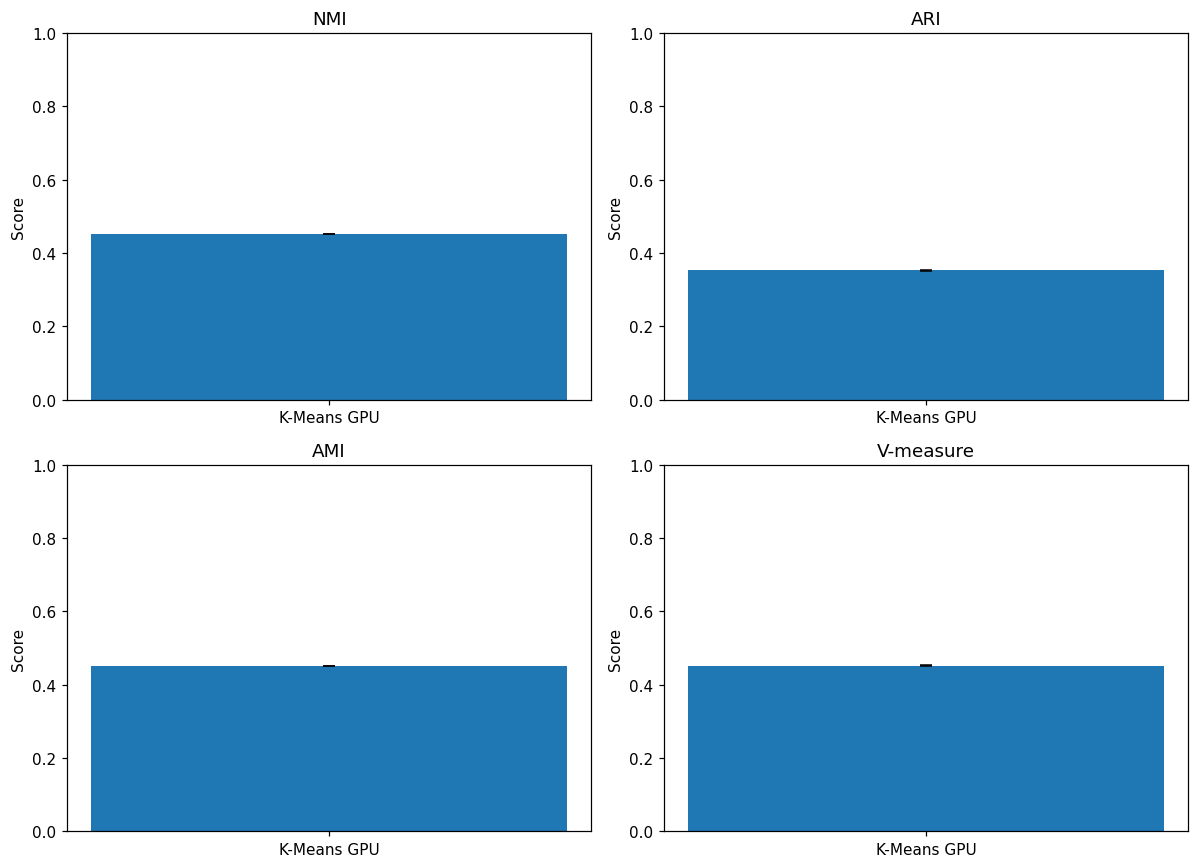

In [12]:
quality_metrics = [
    ("nmi_all", "NMI"),
    ("ari_all", "ARI"),
    ("ami_all", "AMI"),
    ("v_measure", "V-measure"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (metric, title) in zip(
    axes.ravel(),
    quality_metrics,
):
    mean_value = raw_df[metric].mean()
    std_value = raw_df[metric].std()

    ax.bar(
        ["K-Means GPU"],
        [mean_value],
        yerr=[std_value],
        capsize=4,
    )

    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_gpu_external_metrics.png",
    dpi=160,
)
plt.show()


## 13. Internal clustering-quality plots

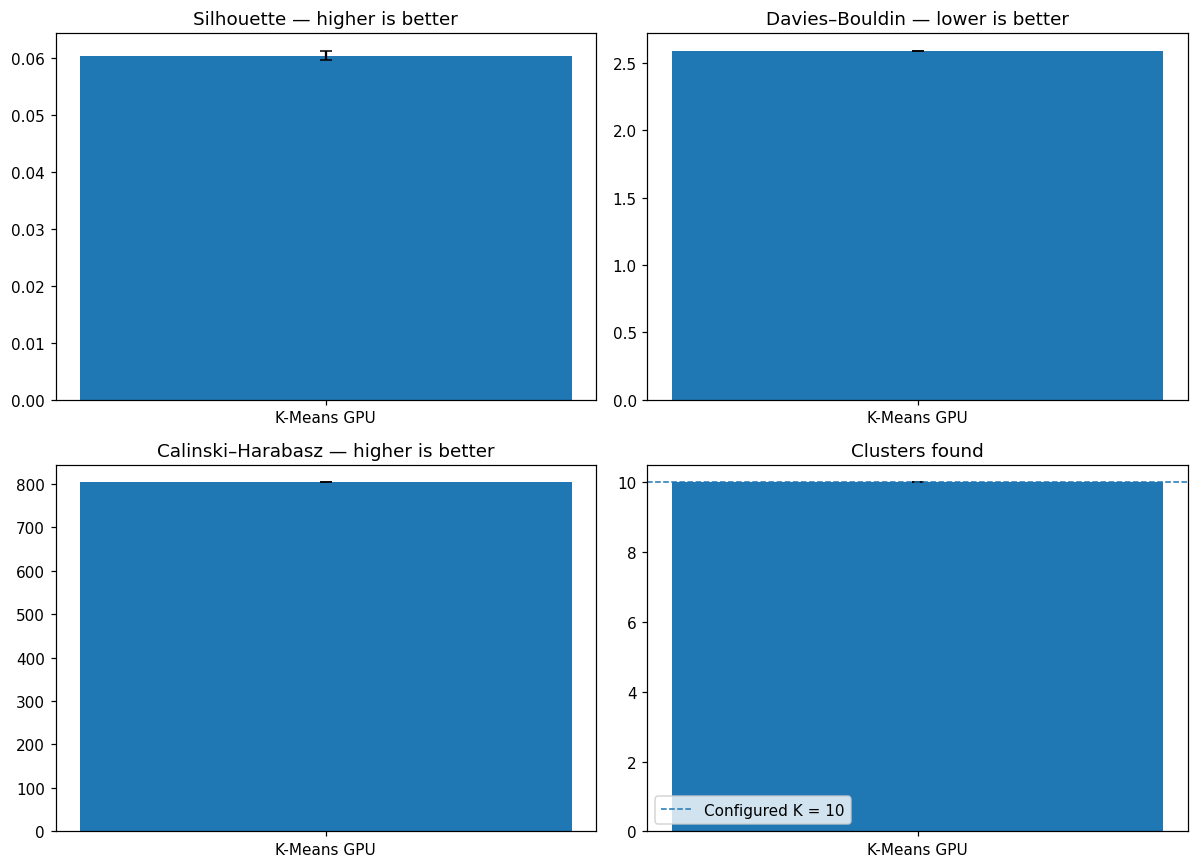

In [13]:
internal_metrics = [
    ("silhouette", "Silhouette — higher is better"),
    ("davies_bouldin", "Davies–Bouldin — lower is better"),
    ("calinski_harabasz", "Calinski–Harabasz — higher is better"),
    ("n_clusters", "Clusters found"),
]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

for ax, (metric, title) in zip(
    axes.ravel(),
    internal_metrics,
):
    mean_value = raw_df[metric].mean()
    std_value = raw_df[metric].std()

    ax.bar(
        ["K-Means GPU"],
        [mean_value],
        yerr=[std_value],
        capsize=4,
    )

    ax.set_title(title)

# K should remain 10 for every run.
axes[1, 1].axhline(
    K,
    linestyle="--",
    linewidth=1,
    label="Configured K = 10",
)
axes[1, 1].legend()

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_gpu_internal_metrics.png",
    dpi=160,
)
plt.show()


## 14. Energy, carbon, host RAM, and GPU memory plots


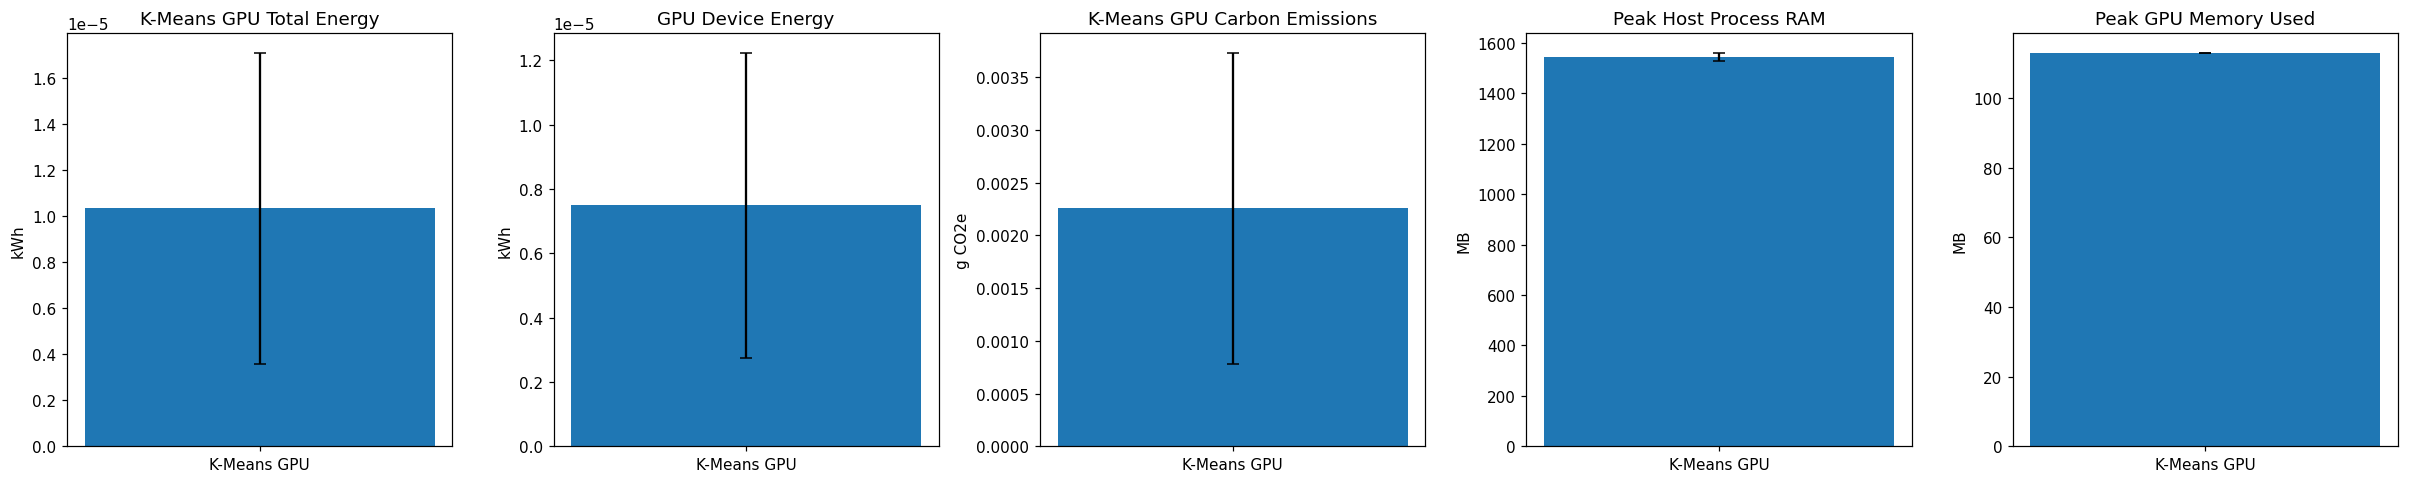

In [14]:
plot_specs = [
    ("energy_kwh", "K-Means GPU Total Energy", "kWh"),
    ("gpu_energy_kwh", "GPU Device Energy", "kWh"),
    ("co2_g", "K-Means GPU Carbon Emissions", "g CO2e"),
    ("peak_process_ram_mb", "Peak Host Process RAM", "MB"),
    ("peak_gpu_memory_mb", "Peak GPU Memory Used", "MB"),
]

fig, axes = plt.subplots(1, 5, figsize=(22, 4.5))

for ax, (metric, title, ylabel) in zip(
    axes,
    plot_specs,
):
    ax.bar(
        ["K-Means GPU"],
        [raw_df[metric].mean()],
        yerr=[raw_df[metric].std()],
        capsize=4,
    )
    ax.set_title(title)
    ax.set_ylabel(ylabel)

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_gpu_energy_carbon_memory.png",
    dpi=160,
)
plt.show()


## 15. 2D PCA visualization of true vs predicted clusters

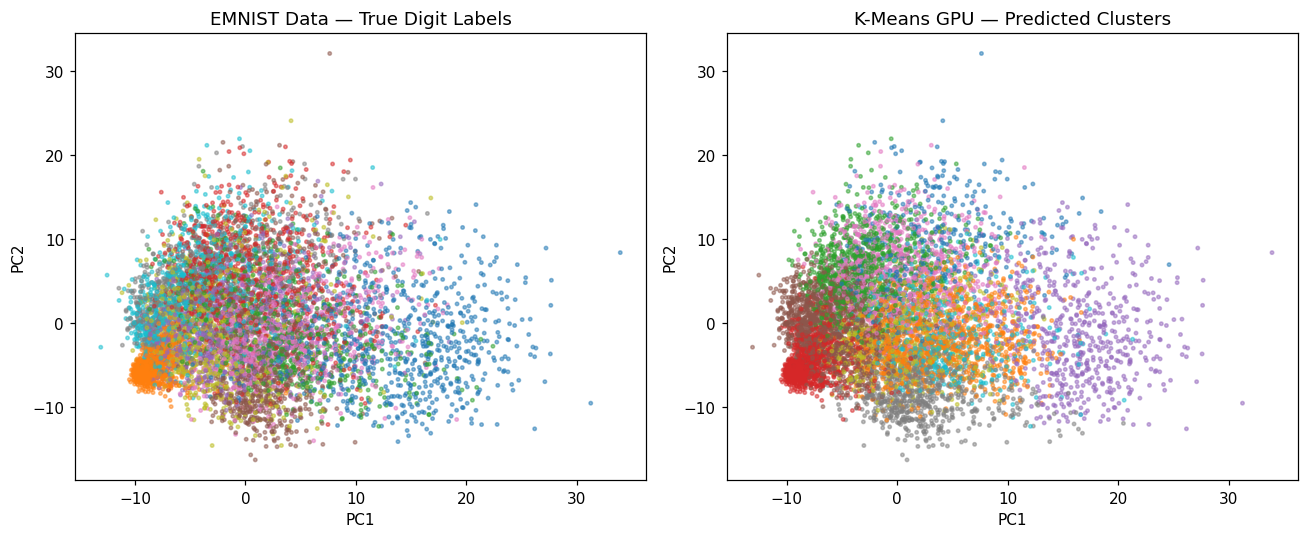

In [15]:
# Use repetition 1 labels for visualization only.
rng = np.random.RandomState(SEED)

z2 = PCA(
    n_components=2,
    random_state=SEED,
).fit_transform(X_shared)

first_result = next(
    result
    for result in results
    if result["repeat"] == 1
)

predicted = first_result["labels"]

sample_idx = rng.permutation(
    len(X_shared)
)[:min(8_000, len(X_shared))]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(
    z2[sample_idx, 0],
    z2[sample_idx, 1],
    c=y_shared[sample_idx],
    s=5,
    cmap="tab10",
    alpha=0.5,
)
axes[0].set_title("EMNIST Data — True Digit Labels")

axes[1].scatter(
    z2[sample_idx, 0],
    z2[sample_idx, 1],
    c=predicted[sample_idx],
    s=5,
    cmap="tab10",
    alpha=0.5,
)
axes[1].set_title("K-Means GPU — Predicted Clusters")

for ax in axes:
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.tight_layout()
plt.savefig(
    "emnist_kmeans_gpu_assignments.png",
    dpi=160,
)
plt.show()


## 16. Compact report table

In [16]:
report_table = pd.DataFrame([{
    "algorithm": "KMeans",
    "device": "gpu",
    "backend": "cuml",
    "samples": int(raw_df["n_samples"].iloc[0]),
    "features_after_pca": int(raw_df["n_features"].iloc[0]),

    "fit_time_s": raw_df["fit_time_s"].mean(),
    "throughput_samples_s": raw_df["throughput_samples_s"].mean(),

    "n_clusters": raw_df["n_clusters"].mean(),

    "nmi": raw_df["nmi_all"].mean(),
    "ari": raw_df["ari_all"].mean(),
    "ami": raw_df["ami_all"].mean(),
    "homogeneity": raw_df["homogeneity"].mean(),
    "completeness": raw_df["completeness"].mean(),
    "v_measure": raw_df["v_measure"].mean(),

    "silhouette": raw_df["silhouette"].mean(),
    "davies_bouldin": raw_df["davies_bouldin"].mean(),
    "calinski_harabasz": raw_df["calinski_harabasz"].mean(),

    "energy_kwh": raw_df["energy_kwh"].mean(),
    "gpu_energy_kwh": raw_df["gpu_energy_kwh"].mean(),
    "co2_g": raw_df["co2_g"].mean(),

    "peak_process_ram_mb": raw_df["peak_process_ram_mb"].mean(),
    "peak_gpu_memory_mb": raw_df["peak_gpu_memory_mb"].mean(),
}])

display(report_table.round(6))


,algorithm,device,backend,samples,features_after_pca,fit_time_s,throughput_samples_s,n_clusters,nmi,ari,ami,homogeneity,completeness,v_measure,silhouette,davies_bouldin,calinski_harabasz,energy_kwh,gpu_energy_kwh,co2_g,peak_process_ram_mb,peak_gpu_memory_mb
0,KMeans,gpu,cuml,20000,50,0.560052,51575.399527,10.0,0.452198,0.352495,0.451708,0.445612,0.458982,0.452198,0.060491,2.592462,803.916931,0.00001,0.000007,0.002259,1543.824219,113.0


## 17. Save outputs

In [17]:
output_dir = (
    Path("/kaggle/working")
    if Path("/kaggle/working").exists()
    else Path(".")
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

raw_df.to_csv(
    output_dir / "kmeans_emnist_gpu_raw_results.csv",
    index=False,
)

summary_df.to_csv(
    output_dir / "kmeans_emnist_gpu_summary.csv",
    index=False,
)

report_table.to_csv(
    output_dir / "kmeans_emnist_gpu_report_table.csv",
    index=False,
)

print("Saved CSV outputs to:", output_dir)
print("PNG plots are also created by the plotting cells.")


Saved CSV outputs to: /kaggle/working
PNG plots are also created by the plotting cells.


# Interpretation and methodological limitations

## What this notebook measures

The benchmark is now:

\[
\boxed{\text{K-Means on GPU}}
\]

It is designed as the GPU counterpart of the CPU-only K-Means notebook.

The principal outputs are:
- clustering fit time;
- throughput;
- peak host process RAM;
- peak GPU memory used;
- estimated total energy consumption;
- estimated GPU device energy;
- estimated CO₂e;
- NMI, AMI, ARI, homogeneity, completeness, and V-measure;
- silhouette, Davies–Bouldin, and Calinski–Harabasz scores.

## Experimental controls retained from the CPU notebook

- fixed 20,000-image EMNIST subset;
- fixed normalization and StandardScaler preprocessing;
- fixed 50-dimensional PCA representation;
- \(K=10\);
- `n_init=10`;
- `max_iter=300`;
- `tol=1e-4`;
- 3 repeated runs;
- true class labels used only for post-clustering evaluation;
- preprocessing excluded from K-Means fit time;
- metric calculation and plotting excluded from fit time.

## GPU timing rule

GPU operations are asynchronous, so CUDA is synchronized immediately before
and after `fit_predict` before the fit time is recorded.

The PCA feature matrix remains a NumPy array, matching the CPU notebook.
The device-to-host transfer of predicted cluster labels is outside fit timing.

## Limitations

1. CodeCarbon estimates energy and CO₂e rather than directly measuring wall-socket electricity.
2. Very short GPU runs can make energy estimates noisy.
3. The GPU can consume non-zero idle power.
4. PCA and scaling are performed once on CPU and are not included in K-Means fit time.
5. Silhouette is evaluated on at most 10,000 samples.
6. EMNIST labels are used only for evaluation after clustering.
7. scikit-learn and cuML are independent K-Means implementations, so small numerical differences may occur even with matched main hyperparameters.
